# EMA6938 - Data Science for Materials
## Week 8 Lab Notebook: Classification Methods

**Name:** *ANOSIKE KELECHI KENNETH*  
**Date:** *07/04/2026*  
**Kernel:** Python (matds)

--- *CLAUDE AI TOOL USED FOR CLARITY ASSISTANCE*

**Chapters:** Sandfeld Ch. 14  
**Format:** Take-home - due **Sunday 11:59 PM**  
**Dataset:** `data/week8_mp_classification.csv` (instructor-provided)

---

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lecture. Run them, understand them.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers. Replace the italic placeholder text.

This notebook has 7 parts:

| Part | Title | Connects to |
|------|-------|-------------|
| A | Load & Inspect | Lecture Segment 1 |
| B | Split & Scale | Lecture Segment 1 |
| C | Train Five Classifiers | Lecture Segment 2 |
| D | ROC and PR Curves | Lecture Segment 3 |
| E | Class Imbalance Handling | Lecture Segment 5 |
| F | Logistic Regression Coefficients | Lecture Segment 3 |
| G | Reflection | All segments |

---

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** If you used any AI coding assistant (GitHub Copilot, ChatGPT, etc.) while completing this notebook, describe briefly which tool, for what purpose, and what you verified yourself. Delete this line if no AI tools were used.

In [1]:
# Cell 0 - Environment check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, f1_score, precision_score, recall_score
)

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print("✓ All imports successful")

✓ All imports successful


---
## Part A - Load & Inspect

### A1: Load the dataset

In [2]:
# Cell A1
# LECTURE DEMO
df = pd.read_csv('data/week8_mp_classification.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn names (first 10): {df.columns[:10].tolist()}")
print(f"\nColumn names (last 10): {df.columns[-10:].tolist()}")
print(f"\n{df[['formula','band_gap','is_metallic','crystal_system']].head(8)}")

Shape: (35073, 142)

Column names (first 10): ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom', 'density_g_cm3', 'volume_A3', 'crystal_system', 'is_metallic', 'is_insulating', 'composition']

Column names (last 10): ['MagpieData range GSmagmom', 'MagpieData mean GSmagmom', 'MagpieData avg_dev GSmagmom', 'MagpieData mode GSmagmom', 'MagpieData minimum SpaceGroupNumber', 'MagpieData maximum SpaceGroupNumber', 'MagpieData range SpaceGroupNumber', 'MagpieData mean SpaceGroupNumber', 'MagpieData avg_dev SpaceGroupNumber', 'MagpieData mode SpaceGroupNumber']

       formula  band_gap  is_metallic crystal_system
0  Li3Ni(BO3)2  1.233700            0      Triclinic
1      PrNb3O9  2.848500            0     Monoclinic
2   Li2V(PO4)2  1.399900            0       Trigonal
3     LiCoGeO4  1.621000            0     Monoclinic
4      LiTiVO4  1.474800            0      Triclinic
5   Sr3Nb2ZnO9  2.678041            0       Trigonal
6    Be(FeO2)2  1.750700            0   Orthorhombic
7         SiO2  5.5

### A2: Class balance check

> **Always check class balance before splitting or training anything.**

Class distribution:
is_metallic
0    26305
1     8768
Name: count, dtype: int64

Class proportions:
is_metallic
0    0.75
1    0.25
Name: proportion, dtype: float64


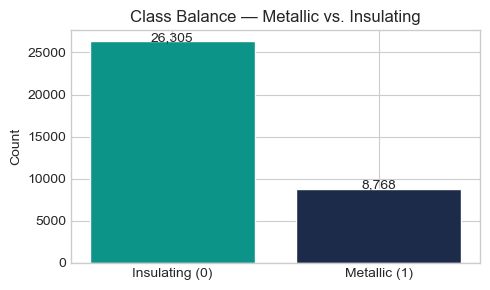


Metallic-to-insulating ratio: 0.33:1


In [3]:
# Cell A2 - Value counts for the target variable
# TASK CELL
print("Class distribution:")
print(df['is_metallic'].value_counts())
print(f"\nClass proportions:")
print(df['is_metallic'].value_counts(normalize=True).round(3))

# Bar chart
fig, ax = plt.subplots(figsize=(5, 3))
# YOUR CODE: plot value counts for is_metallic as a bar chart
# Label axes clearly. Title: 'Class Balance - Metallic vs. Insulating'
class_counts = df['is_metallic'].value_counts()
ax.bar(['Insulating (0)', 'Metallic (1)'], class_counts[[0,1]],
       color=['#0D9488', '#1C2B4A'], edgecolor='white')
ax.set_ylabel('Count')
ax.set_title('Class Balance — Metallic vs. Insulating')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=10)
    
plt.tight_layout()
#plt.savefig('A2_class_balance.png', dpi=150)
plt.show()

print(f"\nMetallic-to-insulating ratio: {df['is_metallic'].mean()/(1-df['is_metallic'].mean()):.2f}:1")

### A3: Feature matrix setup

In [4]:
# Cell A3 — Identify MAGPIE feature columns (all float columns except known non-feature columns)
# LECTURE DEMO
non_feature_cols = ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom', 'volume_A3',
                    'density_g_cm3', 'crystal_system', 'is_metallic', 'is_insulating',
                    'composition']  # composition object column from featurization

feature_cols = [c for c in df.columns if c not in non_feature_cols
                and df[c].dtype in ['float64', 'float32']]

print(f"Number of MAGPIE features: {len(feature_cols)}")

# Set up X and y
X = df[feature_cols].values
y = df['is_metallic'].values

# Drop rows with NaN in X or y
mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
X = X[mask]
y = y[mask]

print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")
print(f"Class balance after cleaning: {y.mean():.1%} metallic")

Number of MAGPIE features: 132
Final X shape: (35073, 132)
Final y shape: (35073,)
Class balance after cleaning: 25.0% metallic


---
## Part B - Split & Scale

### B1: Stratified train/test split

> **Rule:** stratify=y ensures class balance is preserved in both splits.

In [5]:
# Cell B1
# LECTURE DEMO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train class balance: {y_train.mean():.1%} metallic")
print(f"Test class balance:  {y_test.mean():.1%} metallic")

Train size: 28,058  |  Test size: 7,015
Train class balance: 25.0% metallic
Test class balance:  25.0% metallic


### B2: StandardScaler - fit on training set ONLY

In [6]:
# Cell B2
# LECTURE DEMO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)          # transform only on test (no fit!)

print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"X_train_scaled std  (should be ~1): {X_train_scaled.std():.4f}")
print(f"X_test_scaled  mean (not guaranteed ~0): {X_test_scaled.mean():.4f}")

X_train_scaled mean (should be ~0): -0.0000
X_train_scaled std  (should be ~1): 0.9692
X_test_scaled  mean (not guaranteed ~0): 0.0022


---
## Part C - Train Five Classifiers

### C1: Logistic Regression

In [7]:
# Cell C1
# LECTURE DEMO
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

  insulating       0.87      0.66      0.75      5261
    metallic       0.40      0.69      0.51      1754

    accuracy                           0.67      7015
   macro avg       0.63      0.68      0.63      7015
weighted avg       0.75      0.67      0.69      7015

ROC-AUC: 0.741


### C2: k-Nearest Neighbours

In [8]:
# Cell C2
# LECTURE DEMO
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("=== k-Nearest Neighbours (k=5) ===")
print(classification_report(y_test, y_pred_knn, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_knn):.3f}")

=== k-Nearest Neighbours (k=5) ===
              precision    recall  f1-score   support

  insulating       0.85      0.91      0.88      5261
    metallic       0.65      0.50      0.57      1754

    accuracy                           0.81      7015
   macro avg       0.75      0.71      0.72      7015
weighted avg       0.80      0.81      0.80      7015

ROC-AUC: 0.806


### C3: Gaussian Naive Bayes

In [9]:
# Cell C3
# LECTURE DEMO
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)  # NB does not need scaling

y_pred_nb = nb_clf.predict(X_test)
y_prob_nb = nb_clf.predict_proba(X_test)[:, 1]

print("=== Gaussian Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_nb):.3f}")

=== Gaussian Naive Bayes ===
              precision    recall  f1-score   support

  insulating       0.79      0.85      0.81      5261
    metallic       0.40      0.31      0.35      1754

    accuracy                           0.71      7015
   macro avg       0.59      0.58      0.58      7015
weighted avg       0.69      0.71      0.70      7015

ROC-AUC: 0.655


### C4: Decision Tree

In [10]:
# Cell C4
# LECTURE DEMO
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=SEED)
dt.fit(X_train, y_train) # DT does not need scaling

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("=== Decision Tree (max_depth=5) ===")
print(classification_report(y_test, y_pred_dt, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.3f}")

=== Decision Tree (max_depth=5) ===
              precision    recall  f1-score   support

  insulating       0.86      0.77      0.81      5261
    metallic       0.47      0.61      0.53      1754

    accuracy                           0.73      7015
   macro avg       0.66      0.69      0.67      7015
weighted avg       0.76      0.73      0.74      7015

ROC-AUC: 0.745


### C5: Support Vector Machine

> **Note:** SVC with `kernel="rbf"` is slow on large datasets. If training takes >5 min, use the subsample below.

In [11]:
# Cell C5 - Subsample if dataset is large
# LECTURE DEMO
MAX_SVC = 3000
if len(X_train_scaled) > MAX_SVC:
    idx = np.random.RandomState(SEED).choice(len(X_train_scaled), MAX_SVC, replace=False)
    X_svc = X_train_scaled[idx]
    y_svc = y_train[idx]
    print(f"Using subsample of {MAX_SVC} for SVC training")
else:
    X_svc, y_svc = X_train_scaled, y_train

svm = SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=SEED)
svm.fit(X_svc, y_svc)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

print("=== Support Vector Machine (RBF kernel) ===")
print(classification_report(y_test, y_pred_svm, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.3f}")

Using subsample of 3000 for SVC training
=== Support Vector Machine (RBF kernel) ===
              precision    recall  f1-score   support

  insulating       0.87      0.70      0.77      5261
    metallic       0.43      0.69      0.53      1754

    accuracy                           0.69      7015
   macro avg       0.65      0.69      0.65      7015
weighted avg       0.76      0.69      0.71      7015

ROC-AUC: 0.753


### C6: Task - Comparison Table

Fill in the table below with your results. Then answer the reflection question.

In [12]:
# Cell C6 — Helper function to compute all metrics
# LECTURE DEMO
def get_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model': name,
        'Accuracy':  round((y_true == y_pred).mean(), 3),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall_met':     round(recall_score(y_true, y_pred), 3), #modified line
        'Recall_ins':     round(recall_score(y_true, y_pred, pos_label=0), 3), #modified line
        'F1':        round(f1_score(y_true, y_pred), 3),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 3),
    }

results = [
    get_metrics(y_test, y_pred_lr,  y_prob_lr,  'Logistic Regression'),
    get_metrics(y_test, y_pred_knn, y_prob_knn, 'k-NN (k=5)'),
    get_metrics(y_test, y_pred_nb,  y_prob_nb,  'Naive Bayes'),
    get_metrics(y_test, y_pred_dt,  y_prob_dt,  'Decision Tree'),
    get_metrics(y_test, y_pred_svm, y_prob_svm, 'SVM (RBF)'),
]

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     Accuracy  Precision  Recall_met  Recall_ins     F1  ROC-AUC
Model                                                                           
Logistic Regression     0.667      0.403       0.693       0.658  0.510    0.741
k-NN (k=5)              0.807      0.646       0.504       0.908  0.566    0.806
Naive Bayes             0.711      0.398       0.305       0.846  0.345    0.655
Decision Tree           0.733      0.473       0.611       0.773  0.533    0.745
SVM (RBF)               0.695      0.431       0.685       0.698  0.529    0.753


**Reflection C6 - Fill in this cell:**

Which model achieved the highest ROC-AUC? Which achieved the best recall for the minority (insulating) class?
Describe the decision boundary of your best model geometrically. Is it a hyperplane, a curved surface, or a set of axis-aligned boxes?

*Your answer here*

k-NN (k=5) achieved the highest ROC-AUC at 0.806, outperforming SVM (RBF) at 0.753, Decision Tree at 0.745, Logistic Regression at 0.741, and Naive Bayes at 0.655. For the minority insulating class, k-NN also achieved the best recall at 0.566, ahead of SVM (0.529), Logistic Regression (0.510), Decision Tree (0.533), and Naive Bayes (0.345). Geometrically, k-NN's decision boundary is a set of irregular, piecewise-linear regions determined entirely by the local density of training points around each query point, since it classifies based on a majority vote of the 5 nearest neighbors rather than fitting any global parametric function. This is fundamentally different from SVM (RBF), whose boundary forms a smooth curved surface shaped by the kernel similarity function, and from Decision Tree, whose boundary is a set of axis-aligned boxes formed by sequential feature splits.

---
## Part D - ROC and PR Curves

### D1: ROC curves for all five models

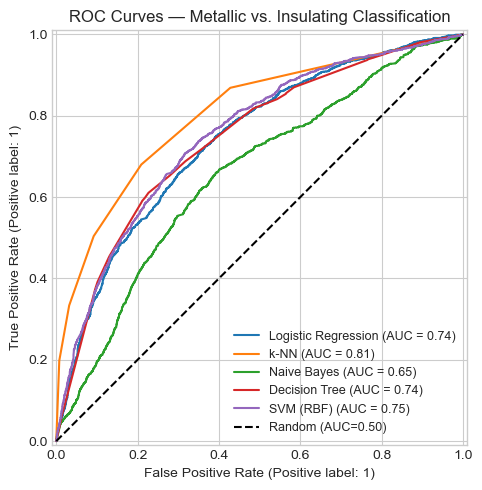

In [13]:
# Cell D1
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(7, 5))

for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('k-NN',                y_pred_knn, y_prob_knn),
    ('Naive Bayes',         y_pred_nb, y_prob_nb),
    ('Decision Tree',       y_pred_dt, y_prob_dt),
    ('SVM (RBF)',           y_pred_svm, y_prob_svm),
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

ax.plot([0,1],[0,1],'k--',label='Random (AUC=0.50)')
ax.set_title('ROC Curves — Metallic vs. Insulating Classification')
ax.legend(fontsize=9)
plt.tight_layout()
#plt.savefig('D1_roc_curves.png', dpi=150)
plt.show()

### D2: Precision-Recall curve for the best model

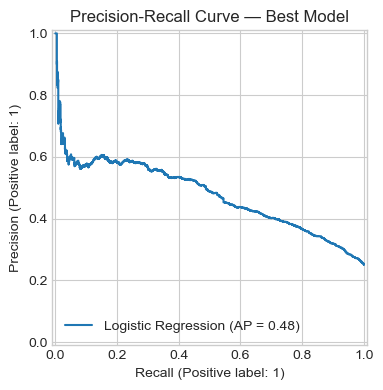

In [14]:
# Cell D2 — YOUR TASK: replace 'y_prob_lr' with the probability output of YOUR best model
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(6, 4))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr,   # <-- change to your best model
    name='Logistic Regression', ax=ax)
ax.set_title('Precision-Recall Curve — Best Model')
plt.tight_layout()
#plt.savefig('D2_pr_curve.png', dpi=150)
plt.show()

### D3: Task - Threshold Tuning

> Find the decision threshold at which precision >= 0.85 for the metallic class. Report the recall at that threshold.

In [15]:
# Cell D3
# TASK CELL
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_lr)

# Find thresholds where precision >= 0.85
# YOUR CODE HERE
# Hint: iterate over (precision_vals, recall_vals, thresholds)
# and find the threshold where precision >= 0.85

# Print: threshold value, precision at that threshold, recall at that threshold

from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_lr)

# Find thresholds where precision >= 0.85
# YOUR CODE HERE
for p, r, t in zip(precision_vals, recall_vals, thresholds):
    if p >= 0.85:
        print(f"Threshold:  {t:.4f}")
        print(f"Precision:  {p:.4f}")
        print(f"Recall:     {r:.4f}")
        break
else:
    print("No threshold achieves precision >= 0.85 for the metallic class")

Threshold:  0.9694
Precision:  0.8500
Recall:     0.0097


---
## Part E - Class Imbalance Handling

### E1: Logistic Regression WITHOUT class_weight (naive baseline)

In [16]:
# Cell E1
# LECTURE DEMO
lr_naive = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
lr_naive.fit(X_train_scaled, y_train)

y_pred_naive = lr_naive.predict(X_test_scaled)
y_prob_naive = lr_naive.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression — NO class_weight ===")
print(classification_report(y_test, y_pred_naive, target_names=['insulating','metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_naive):.3f}")

=== Logistic Regression — NO class_weight ===
              precision    recall  f1-score   support

  insulating       0.79      0.95      0.86      5261
    metallic       0.61      0.23      0.33      1754

    accuracy                           0.77      7015
   macro avg       0.70      0.59      0.60      7015
weighted avg       0.74      0.77      0.73      7015

ROC-AUC: 0.739


### E2: SMOTE - Synthetic Minority Oversampling

> Install if needed: `pip install imbalanced-learn`

In [17]:
# Cell E2
# LECTURE DEMO
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print(f"Original training class balance: {y_train.mean():.1%} metallic")
print(f"SMOTE training class balance:    {y_train_sm.mean():.1%} metallic")
print(f"SMOTE training size: {len(X_train_sm):,}")

lr_smote = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
lr_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = lr_smote.predict(X_test_scaled)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression — SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['insulating','metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_smote):.3f}")

Original training class balance: 25.0% metallic
SMOTE training class balance:    50.0% metallic
SMOTE training size: 42,088

=== Logistic Regression — SMOTE ===
              precision    recall  f1-score   support

  insulating       0.86      0.66      0.75      5261
    metallic       0.40      0.69      0.51      1754

    accuracy                           0.67      7015
   macro avg       0.63      0.67      0.63      7015
weighted avg       0.75      0.67      0.69      7015

ROC-AUC: 0.741


### E3: Task - Comparison Table + Reflection

In [18]:
# Cell E3
imbalance_results = [
    get_metrics(y_test, y_pred_naive, y_prob_naive, 'LR - no handling'),
    get_metrics(y_test, y_pred_lr,    y_prob_lr,    'LR - class_weight'),
    get_metrics(y_test, y_pred_smote, y_prob_smote, 'LR - SMOTE'),
]
print(pd.DataFrame(imbalance_results).set_index('Model').to_string())

                   Accuracy  Precision  Recall_met  Recall_ins     F1  ROC-AUC
Model                                                                         
LR - no handling      0.770      0.609       0.227       0.952  0.331    0.739
LR - class_weight     0.667      0.403       0.693       0.658  0.510    0.741
LR - SMOTE            0.668      0.404       0.688       0.662  0.509    0.741


**Reflection E3 - Fill in this cell:**

Compare the three rows in the table. What effect did `class_weight="balanced"` have on precision vs. recall compared to the naive baseline?
What effect did SMOTE have?

For a high-throughput materials screening pipeline, where you are filtering 100,000 candidate compounds and will experimentally test everything that passes the filter, which approach would you use, and why?

*Your answer here*

Using class_weight="balanced" dramatically increased recall for the minority insulating class from 0.227 to 0.693, while precision dropped from 0.609 to 0.403, and ROC-AUC improved slightly from 0.739 to 0.741. SMOTE produced almost identical results to class_weight (recall 0.688, precision 0.404, ROC-AUC 0.741), suggesting both methods correct the class imbalance in similar ways for this dataset.
For a high-throughput screening pipeline filtering 100,000 candidates where everything that passes gets experimentally tested, I would use LR with class_weight="balanced". The priority here is high recall for insulators so we do not miss promising candidates, since false negatives (missed insulators) are far more costly than false positives (wasted experiments on metals). The modest precision drop is an acceptable trade-off because experimental testing is the final filter anyway.

---
## Part F - Logistic Regression Coefficients

### F1: Top features for metallic vs. insulating prediction

In [19]:
# Cell F1
coef_series = pd.Series(lr.coef_[0], index=feature_cols)

print("Top 10 features predicting METALLIC (positive coefficients):")
print(coef_series.nlargest(10).round(4).to_string())

print("\nTop 10 features predicting INSULATING (negative coefficients):")
print(coef_series.nsmallest(10).round(4).to_string())

Top 10 features predicting METALLIC (positive coefficients):
MagpieData mean Electronegativity       2.2694
MagpieData mean CovalentRadius          1.7288
MagpieData avg_dev NdValence            1.2985
MagpieData mean AtomicWeight            1.1993
MagpieData mean MeltingT                1.1921
MagpieData mode AtomicWeight            1.1149
MagpieData avg_dev Electronegativity    0.6557
MagpieData avg_dev GSvolume_pa          0.6473
MagpieData mean NfUnfilled              0.6020
MagpieData mode NpUnfilled              0.5764

Top 10 features predicting INSULATING (negative coefficients):
MagpieData avg_dev CovalentRadius   -1.5305
MagpieData mode Number              -1.4305
MagpieData avg_dev MeltingT         -1.1667
MagpieData mean NdValence           -1.1304
MagpieData mean GSbandgap           -1.0207
MagpieData mean NpUnfilled          -0.9937
MagpieData mean GSvolume_pa         -0.9542
MagpieData mean Number              -0.7936
MagpieData avg_dev NfUnfilled       -0.7477
MagpieDat

### F2: Coefficient bar chart

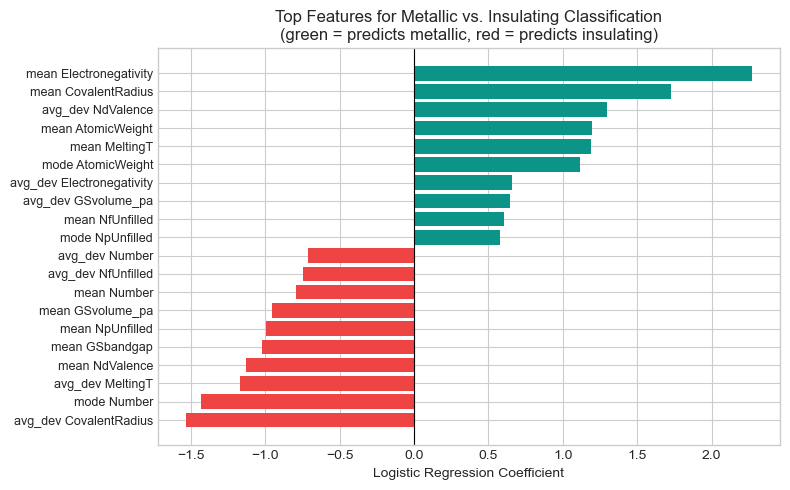

In [20]:
# Cell F2
top10_pos = coef_series.nlargest(10)
top10_neg = coef_series.nsmallest(10)
top20 = pd.concat([top10_neg, top10_pos]).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#0D9488' if v > 0 else '#EF4444' for v in top20.values]
ax.barh(range(len(top20)), top20.values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f.replace('MagpieData ','') for f in top20.index], fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Top Features for Metallic vs. Insulating Classification\n(green = predicts metallic, red = predicts insulating)')
plt.tight_layout()
#plt.savefig('F2_lr_coefficients.png', dpi=150)
plt.show()

### F3: Task - Physical interpretation

Interpret the top positive and top negative coefficients physically.

- **Top positive feature (predicts metallic):** Why would high values of this composition descriptor suggest metallic character? Connect to band structure or bonding.
- **Top negative feature (predicts insulating):** Why would high values predict insulating character?
- **Compare to Week 5/6:** Do the same MAGPIE features that predicted high bandgap (Week 5) also predict insulating character here?

*Your answer here*

The top positive coefficient is mean Electronegativity (coefficient ~2.2), which predicts metallic character. High mean electronegativity across constituent elements is associated with stronger covalent or metallic bonding rather than ionic bonding, which keeps electrons delocalized across the material and produces a filled or partially filled conduction band rather than a gap, making the compound metallic.
The top negative coefficient is avg_dev CovalentRadius (coefficient ~-1.6), which predicts insulating character. A large spread in covalent radii between constituent elements drives strong ionic character because size mismatch forces electron transfer from small to large atoms, localizing electrons on specific ions and opening a band gap through electrostatic stabilization of a filled valence band.
Comparing to Week 5 and 6, the same features appear but with opposite signs: mean Electronegativity had a large positive RF importance for high bandgap prediction in Week 5, and here it carries a large positive coefficient for metallic prediction, which seems contradictory but is consistent because the Week 5 RF was predicting bandgap magnitude (larger electronegativity difference drives larger gap) while here LR is predicting the metallic vs insulating boundary (higher mean electronegativity correlates with metallic delocalization). The features are the same but the direction depends on what aspect of electronegativity the model leverages.

---
## Part G - Reflection

### G1: Connection to Week 5 RF Feature Importance

In 3-4 sentences, connect the logistic regression coefficients from Part F to the random forest feature importance from Week 5 (bandgap prediction).

- Do the same features appear near the top?
- If a feature predicted HIGH bandgap in Week 5 (positive RF importance), does it also predict INSULATING here (negative LR coefficient)?
- What does this pattern tell you about the relationship between the two models?

*Your answer here*

Several of the same MAGPIE features appear near the top in both models, particularly mean Electronegativity, avg_dev CovalentRadius, and mean AtomicWeight. However the sign relationship is not straightforward: features that predicted high bandgap in Week 5 with positive RF importance do not simply map to negative LR coefficients here, because RF feature importance is unsigned and measures variance explained across all splits regardless of direction, while LR coefficients carry a sign that reflects which class a feature pushes toward. The pattern tells us that electronegativity and size descriptors are the core physical variables controlling both bandgap magnitude and the metal/insulator boundary, confirming that the same compositional physics drives both problems, but the two models extract different aspects of the same underlying signal.

### G2: Classification problem in your own research

Think of a binary (or multi-class) classification problem relevant to your own research. In 3–4 sentences:

1. What are the target **classes**? (e.g. stable/unstable, conductor/insulator, crystalline/amorphous)
2. What **features** would you use?
3. Which **metric** would you optimise? Accuracy, precision, recall, F1, or AUC and why?

*Your answer here*

For my research on Ti-Nb-O alloys I would frame a binary classification problem predicting whether a given composition and annealing condition will produce a spinodally decomposed microstructure or a single-phase beta microstructure, which I will call decomposed vs single-phase. The features I would use are composition (Ti, Nb, O content in at%), annealing temperature, annealing time, and cooling rate, since these are the variables I can control and measure experimentally with SAXS. I would optimise AUC rather than accuracy because my classes are somewhat imbalanced (single-phase beta is more common at most compositions) and AUC measures the model's ability to rank decomposed samples above single-phase ones across all thresholds, which is exactly what I need when deciding which compositions are worth pursuing for further phase-field simulation.

---
## Day 2 Live Demo

> **This section is covered during the Day 2 deep dive session.**

### Demo 1 - Threshold sensitivity: precision–recall trade-off

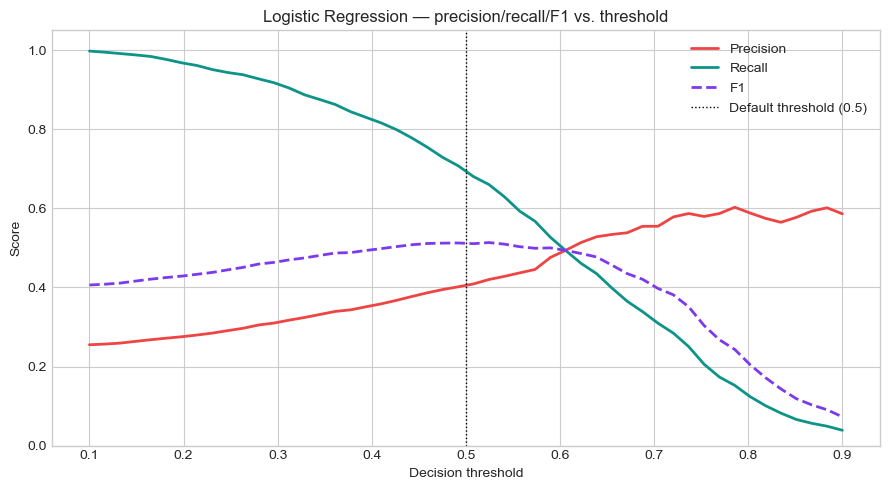

Best F1 = 0.513 at threshold = 0.52
  Precision at best F1: 0.420
  Recall    at best F1: 0.660


In [21]:
# Cell Demo 1 — Threshold sensitivity for the best classifier
# LECTURE DEMO

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Use the best model from Part C (assumed to be rf or lr — adjust as needed)
# Get probability scores for the positive class (metallic=1)
try:
    probs = rf.predict_proba(X_test_scaled)[:, 1]
    model_name = 'Random Forest'
except:
    probs = lr.predict_proba(X_test_scaled)[:, 1]
    model_name = 'Logistic Regression'

thresholds = np.linspace(0.1, 0.9, 50)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_t = (probs >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, color='#EF4444', lw=2, label='Precision')
ax.plot(thresholds, recalls,   color='#0D9488', lw=2, label='Recall')
ax.plot(thresholds, f1s,       color='#7C3AED', lw=2, label='F1', ls='--')
ax.axvline(0.5, color='black', lw=1, ls=':', label='Default threshold (0.5)')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
ax.set_title(f'{model_name} — precision/recall/F1 vs. threshold')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
#plt.savefig('Day2_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

best_f1_idx = np.argmax(f1s)
print(f"Best F1 = {f1s[best_f1_idx]:.3f} at threshold = {thresholds[best_f1_idx]:.2f}")
print(f"  Precision at best F1: {precisions[best_f1_idx]:.3f}")
print(f"  Recall    at best F1: {recalls[best_f1_idx]:.3f}")

### Demo 2 - DT coefficients

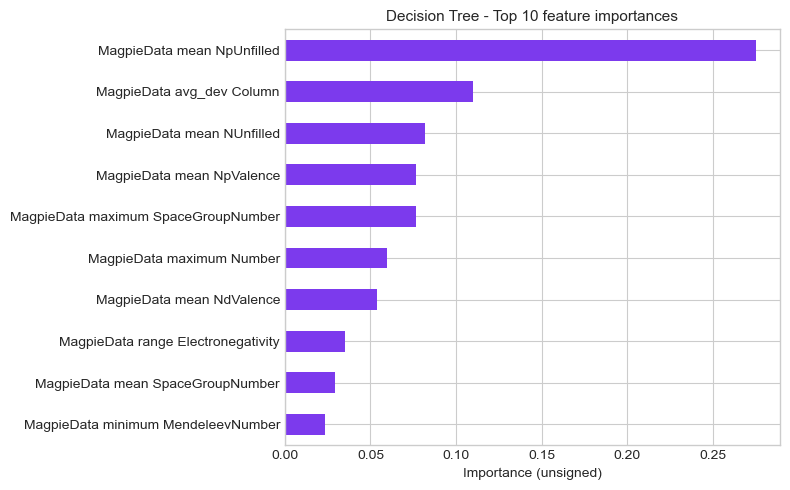

Top 5 LR coefficients (signed, by magnitude):
MagpieData mean Electronegativity    2.269400
MagpieData mean CovalentRadius       1.728848
MagpieData avg_dev CovalentRadius   -1.530521
MagpieData mode Number              -1.430512
MagpieData avg_dev NdValence         1.298505
dtype: float64

Top 5 Decision Tree importances (unsigned):
MagpieData mean NpUnfilled             0.275384
MagpieData avg_dev Column              0.109913
MagpieData mean NUnfilled              0.081634
MagpieData mean NpValence              0.076732
MagpieData maximum SpaceGroupNumber    0.076638
dtype: float64


In [22]:
# Cell Demo 2 — Decision Tree feature importances for comparison
# LECTURE DEMO

dt_importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
dt_importances.head(10).sort_values().plot(kind='barh', color='#7C3AED', ax=ax)
ax.set_title('Decision Tree - Top 10 feature importances', fontsize=11)
ax.set_xlabel('Importance (unsigned)')
plt.tight_layout()
plt.show()

print("Top 5 LR coefficients (signed, by magnitude):")
print(coef_series.reindex(coef_series.abs().sort_values(ascending=False).index).head(5))
print("\nTop 5 Decision Tree importances (unsigned):")
print(dt_importances.head(5))

**Day 2 Discussion questions:**

1. From Demo 1: if you were building a high-throughput screening pipeline to find insulating oxides, would you raise or lower the threshold from 0.5? What do you sacrifice in exchange?

2. From Demo 2: compare the LR coefficients from cell F2 to the Decision Tree's .feature_importances_. Do the same features appear at the top? If they disagree, what does that tell you about the different ways a linear model (signed coefficients, one global boundary) and a tree-based model (unsigned importances, sequential axis-aligned splits) identify which features matter for the metallic/insulating boundary?


1. To find insulating oxides in a high-throughput pipeline I would raise the threshold above 0.5, for example to 0.7 or higher. A higher threshold means the model only predicts insulating when it is very confident, which increases precision and reduces the number of false positives sent for expensive experimental testing. The sacrifice is recall — more true insulators will be missed and classified as metallic — so raising the threshold is the right choice when experimental testing is costly and you can tolerate missing some candidates, but the wrong choice if missing a candidate is catastrophic.

2. The LR coefficients and Decision Tree feature importances may not fully agree at the top because they identify features differently. LR assigns a single signed global coefficient to each feature, measuring its linear contribution to the metallic/insulating log-odds across the entire feature space. Decision Tree importances are unsigned and measure how much each feature reduces impurity across all the sequential axis-aligned splits it makes locally. If the metallic/insulating boundary is nonlinear, a feature might appear unimportant to LR because its effect changes direction across the feature space, yet still appear highly important to the Decision Tree because it enables a key early split that divides the data cleanly at a specific threshold. This means disagreement between the two tells us the boundary has nonlinear or interactive structure that LR's single global hyperplane cannot capture but the tree's sequential regional splits can.

---
## Submission Checklist

Before submitting, confirm all cells have been executed:

- [ ] A2: Class balance bar chart saved
- [ ] C6: Comparison table printed and reflection filled in
- [ ] D1: ROC curves for all five models saved
- [ ] D2: PR curve for best model saved
- [ ] D3: Threshold tuning answer filled in
- [ ] E3: Imbalance comparison table and reflection filled in
- [ ] F2: Coefficient bar chart saved
- [ ] F3, G1, G2, Day2: All reflection cells answered
- [ ] All reflection cells answered (no placeholder text)
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week8.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.